In [ ]:
import sys
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tf_keras as keras
sys.modules["tensorflow.keras"] = keras
sys.modules["keras"] = keras

import keras_tuner as kt
import qkeras
from qkeras import QDense
from qkeras.quantizers import quantized_bits, quantized_relu

import tensorflow as tf
from tf_keras.models import Sequential
from tf_keras.layers import MaxPooling2D, Activation, Flatten, Dropout
import numpy as np

2026-04-28 12:24:08.781073: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf

tf.random.set_seed(seed)
import os

#os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

In [3]:
X_train_val = np.load('X_train_val.npy')
X_test = np.load('X_test.npy')
y_train_val = np.load('y_train_val.npy')
y_test = np.load('y_test.npy')
classes = np.load('classes.npy', allow_pickle=True)

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from tensorflow.keras.layers import Activation
from qkeras.qlayers import QDense, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu

In [ ]:
model = Sequential()
model.add(
    QDense(
        64,
        input_shape=(16,),
        name='fc1',
        kernel_quantizer=quantized_bits(6, 0, alpha=1),
        bias_quantizer=quantized_bits(6, 0, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(1e-4),
    )
)
model.add(QActivation(activation=quantized_relu(6), name='relu1'))
model.add(
    QDense(
        32,
        name='fc2',
        kernel_quantizer=quantized_bits(6, 0, alpha=1),
        bias_quantizer=quantized_bits(6, 0, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(1e-4),
    )
)
model.add(QActivation(activation=quantized_relu(6), name='relu2'))
model.add(
    QDense(
        32,
        name='fc3',
        kernel_quantizer=quantized_bits(6, 0, alpha=1),
        bias_quantizer=quantized_bits(6, 0, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(1e-4),
    )
)
model.add(QActivation(activation=quantized_relu(6), name='relu3'))
model.add(
    QDense(
        5,
        name='output',
        kernel_quantizer=quantized_bits(6, 0, alpha=1),
        bias_quantizer=quantized_bits(6, 0, alpha=1),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(1e-4),
    )
)
model.add(Activation(activation='softmax', name='softmax'))

I0000 00:00:1777371862.222664    7219 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5273 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [ ]:
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.sparsity import keras as sparsity
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

batch_size = 1024
epochs = 10

# Calculate end_step based on your dataset size
num_samples = len(X_train_val) * 0.75 
steps_per_epoch = np.ceil(num_samples / batch_size).astype(np.int32)
end_step = steps_per_epoch * epochs

pruning_params = {
    'pruning_schedule': sparsity.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.75, # Target 75% sparsity
        begin_step=0,
        end_step=end_step
    )
}

model = tfmot.sparsity.keras.prune_low_magnitude(model, **pruning_params)

In [ ]:
os.makedirs('model_quantized', exist_ok=True)
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, verbose=1),
    ModelCheckpoint(filepath='model_quantized/best_model.weights.h5', monitor='val_accuracy', save_best_only=True, save_weights_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    
    sparsity.UpdatePruningStep(), 
    sparsity.PruningSummaries(log_dir='model_quantized/logs')
]

adam = Adam(learning_rate=1e-3)
model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])

model.fit(
    X_train_val, 
    y_train_val, 
    epochs=epochs, 
    batch_size=batch_size, 
    validation_split=0.25, 
    shuffle=True, 
    callbacks=callbacks
)

# Strip the wrappers to get the plain Keras model back
model = sparsity.strip_pruning(model)
model.save('model_quantized/KERAS_check_best_model.h5')

2026-04-28 12:24:36.409991: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 31872000 exceeds 10% of free system memory.
2026-04-28 12:24:36.552737: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 31872000 exceeds 10% of free system memory.
/home/slopin/hls4ml_proj/venv/lib/python3.12/site-packages/tf_keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


Epoch 1/10


2026-04-28 12:24:42.425842: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b9b341f3940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-28 12:24:42.425890: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-28 12:24:42.458721: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-28 12:24:42.522037: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
I0000 00:00:1777371882.676602   19411 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


486/487 [============================>.] - ETA: 0s - loss: 1.3902 - accuracy: 0.4832
Epoch 1: val_loss improved from inf to 1.19450, saving model to model_quantized/best_model.weights.h5
487/487 [==============================] - 18s 25ms/step - loss: 1.3900 - accuracy: 0.4833 - val_loss: 1.1945 - val_accuracy: 0.5735 - lr: 1.0000e-04
Epoch 2/10
487/487 [==============================] - ETA: 0s - loss: 1.1069 - accuracy: 0.6515
Epoch 2: val_loss improved from 1.19450 to 1.04889, saving model to model_quantized/best_model.weights.h5
487/487 [==============================] - 11s 23ms/step - loss: 1.1069 - accuracy: 0.6515 - val_loss: 1.0489 - val_accuracy: 0.6827 - lr: 1.0000e-04
Epoch 3/10
481/487 [============================>.] - ETA: 0s - loss: 1.0095 - accuracy: 0.6970
Epoch 3: val_loss improved from 1.04889 to 0.97475, saving model to model_quantized/best_model.weights.h5
487/487 [==============================] - 11s 22ms/step - loss: 1.0093 - accuracy: 0.6970 - val_loss: 0.9747

/home/slopin/hls4ml_proj/venv/lib/python3.12/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


% of zeros = 0.5


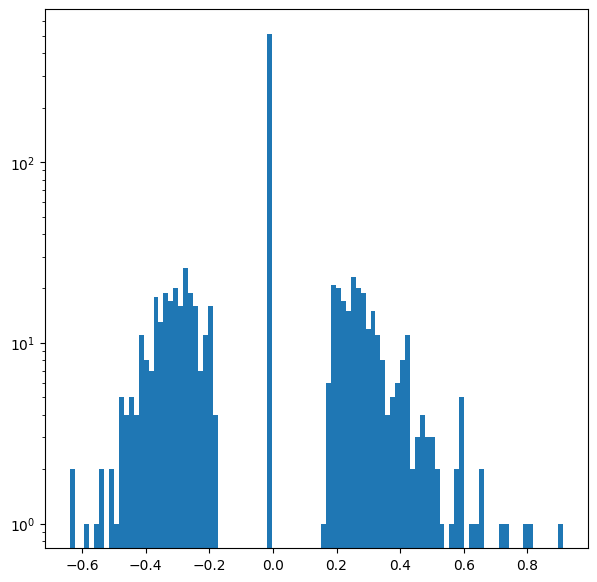

In [8]:
w = model.layers[0].weights[0].numpy()
h, b = np.histogram(w, bins=100)
plt.figure(figsize=(7, 7))
plt.bar(b[:-1], h, width=b[1] - b[0])
plt.semilogy()
print('% of zeros = {}'.format(np.sum(w == 0) / np.size(w)))

In [9]:
model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])

# 3. Evaluate

score = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.8174337148666382
Test accuracy: 0.7318433523178101
